# Wind Comparison between HRDPS and CaSR

In this notebook, we compare the spatial and temporal difference of absolute wind speed, wind speed squared (proportionate to wind stress) and wind speed cubed (proportionate to wind mixing). Wind curl is also calculated. 

4 sets of forcing fields are compared, including high-resolution field `HRDPS`, native low-resolution field `CaSR`, and 2 derived low-resolution fields `HRDPS_coarsened` and `HRDPS__subsampled`. 



See https://journals.ametsoc.org/view/journals/clim/20/23/2007jcli1825.1.xml for the equation to compute the wind stress $\tau$. 

See https://glossary.ametsoc.org/wiki/wind-stress-curl/ for the definition of the curl of wind stress.

## Basic Preparation



In [ ]:
# path

path_casr_u='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc'

path_casr_v='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc'

import sys

sys.path.append("/home/jqiu/analysis-junqi/Tools-Junqi")

import junqi_nctool as jqnc



In [ ]:
# an example of hrdps path
path_hrdps_u=jqnc.nc_path('wind_u',time='2018-01-01',resolution='hourly')

# display variables

jqnc.nc_disp(path_casr_u)

### NetCDF Summary

*Path: : `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc`*

#### Dimensions

Dimension,Size
time,149040
rlat,105
rlon,70


#### Variables

Name,Shape,Dimensions
rotated_pole,(),scalar
CaSR_v3.2_P_UUC_10m,"(149040, 105, 70)","time, rlat, rlon"
time,"(149040,)",time
lon,"(105, 70)","rlat, rlon"
lat,"(105, 70)","rlat, rlon"
rlon,"(70,)",rlon
rlat,"(105,)",rlat


In [2]:
# display variables

jqnc.nc_disp(path_casr_v)

### NetCDF Summary

*Path: : `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc`*

#### Dimensions

Dimension,Size
time,149040
rlat,105
rlon,70


#### Variables

Name,Shape,Dimensions
rotated_pole,(),scalar
CaSR_v3.2_P_VVC_10m,"(149040, 105, 70)","time, rlat, rlon"
time,"(149040,)",time
lon,"(105, 70)","rlat, rlon"
lat,"(105, 70)","rlat, rlon"
rlon,"(70,)",rlon
rlat,"(105,)",rlat


In [7]:
# display variables

jqnc.nc_disp(path_hrdps_u)

### NetCDF Summary

*Path: : `/results/forcing/atmospheric/GEM2.5/operational/ops_y2018m01d01.nc`*

#### Dimensions

Dimension,Size
time_counter,24
y,266
x,256


#### Variables

Name,Shape,Dimensions
atmpres,"(24, 266, 256)","time_counter, y, x"
nav_lat,"(266, 256)","y, x"
nav_lon,"(266, 256)","y, x"
percentcloud,"(24, 266, 256)","time_counter, y, x"
precip,"(24, 266, 256)","time_counter, y, x"
qair,"(24, 266, 256)","time_counter, y, x"
solar,"(24, 266, 256)","time_counter, y, x"
tair,"(24, 266, 256)","time_counter, y, x"
therm_rad,"(24, 266, 256)","time_counter, y, x"
u_wind,"(24, 266, 256)","time_counter, y, x"


### HRDPS

In [9]:
# combine hrdps dataset

import xarray as xr

def variables(ds):
    return ds[['u_wind','v_wind','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

/tmp/ipykernel_3429848/1827557314.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})


In [18]:
# check combined hrdps dataset

print(ds_hrdps)

<xarray.Dataset> Size: 14GB
Dimensions:       (time_counter: 8760, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 70kB 2018-01-01 ... 2018-12-3...
  * x             (x) float64 2kB 0.0 2.5e+03 5e+03 ... 6.35e+05 6.375e+05
  * y             (y) float64 2kB 0.0 2.5e+03 5e+03 ... 6.6e+05 6.625e+05
Data variables:
    u_wind        (time_counter, y, x) float32 2GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
    v_wind        (time_counter, y, x) float32 2GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
    nav_lat       (time_counter, y, x) float64 5GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
    nav_lon       (time_counter, y, x) float64 5GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.0
    History:              Mon Jan  1 10:36:51 2018: ncks -4 -L4 -O /results/f...
    GRIB2_grid_template:  20
    NCO:                  4.4.2


In [10]:
# calculate velocity related variables

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

velocity_hrdps=np.sqrt(ds_hrdps['u_wind']**2+ds_hrdps['v_wind']**2)

# use meter to calculate du/dy and dv/dx

tau_u=ds_hrdps['u_wind']*velocity_hrdps
tau_v=ds_hrdps['v_wind']*velocity_hrdps
ws_curl_hrdps=-tau_u.differentiate('y')+tau_v.differentiate('x')
u_absolute = velocity_hrdps
u_squared = velocity_hrdps**2
u_cubed = velocity_hrdps**3

# calculate mean

mean_u_absolute=u_absolute.mean(dim='time_counter')
mean_u_squared=u_squared.mean(dim='time_counter')
mean_u_cubed=u_cubed.mean(dim='time_counter')
mean_ws_curl_hrdps=ws_curl_hrdps.mean(dim='time_counter')


mean_hrdps_2018=xr.Dataset({
    'mean_velocity': mean_u_absolute,
    'mean_velocity_squared':mean_u_squared,
    'mean_velocity_cubed':mean_u_cubed,
    'mean_ws_curl': mean_ws_curl_hrdps,
    'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_2018_wind_mean.nc"

mean_hrdps_2018.to_netcdf(output_path)

/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45619 instead
  warnings.warn(


Dask Dashboard link: http://127.0.0.1:45619/status


**What's Fun Here**

1. `x` and `y` here represent the length in meter, so we could simply use `differentiate('x')`. However, note that the first grid point `x[0]=0`. Be careful with the boundary of the final results.

2. Use command `top` to see the CPU capacity. 

3. `parallel=True` will activate parallel computation. 

### Native CaSR

In [13]:
# CaSR extraction
import xarray as xr
import numpy as np

path_casr_u='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc'

path_casr_v='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc'

ds_casr_u=xr.open_dataset(path_casr_u)

ds_casr_v=xr.open_dataset(path_casr_v)

# use 'CaSR_v3.2_P_VVC_10m' and 'time'

ds_casr_u_2018=ds_casr_u.sel(time=slice('2018-01-01','2018-12-31'))*0.5144

ds_casr_v_2018=ds_casr_v.sel(time=slice('2018-01-01','2018-12-31'))*0.5144

# print(ds_casr_u_2018)
ds_casr=xr.merge([ds_casr_u_2018['CaSR_v3.2_P_UUC_10m'],ds_casr_v_2018['CaSR_v3.2_P_VVC_10m']])

/tmp/ipykernel_3429848/716845341.py:20: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_casr=xr.merge([ds_casr_u_2018['CaSR_v3.2_P_UUC_10m'],ds_casr_v_2018['CaSR_v3.2_P_VVC_10m']])
/tmp/ipykernel_3429848/716845341.py:20: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_casr=xr.merge([ds_casr_u_2018['CaSR_v3.2_P_UUC_10m'],ds_casr_v_20

In [9]:
print(ds_casr)

<xarray.Dataset> Size: 515MB
Dimensions:              (time: 8760, rlat: 105, rlon: 70)
Coordinates:
  * time                 (time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31...
    lon                  (rlat, rlon) float32 29kB 235.9 236.0 ... 238.0 238.2
    lat                  (rlat, rlon) float32 29kB 43.38 43.42 ... 54.46 54.5
  * rlon                 (rlon) float64 560B -22.8 -22.71 ... -16.68 -16.59
  * rlat                 (rlat) float64 840B -9.45 -9.36 -9.27 ... -0.18 -0.09
Data variables:
    CaSR_v3.2_P_UUC_10m  (time, rlat, rlon) float32 258MB 0.4814 ... -0.2914
    CaSR_v3.2_P_VVC_10m  (time, rlat, rlon) float32 258MB -0.234 ... 0.6501


In [14]:
# calculate velocity and vorticity

import numpy as np

velocity_casr=np.sqrt(ds_casr['CaSR_v3.2_P_UUC_10m']**2+ds_casr['CaSR_v3.2_P_VVC_10m']**2)
velocity_squared=velocity_casr**2
velocity_cubed=velocity_casr**3
# use meter to calculate du/dy and dv/dx

# radius of the earth

R=6371000 # m

tau_u=ds_casr['CaSR_v3.2_P_UUC_10m']*velocity_casr
tau_v=ds_casr['CaSR_v3.2_P_VVC_10m']*velocity_casr

dtau_u_dlat=tau_u.differentiate('rlat')
dtau_v_dlon=tau_v.differentiate('rlon')

# from latitude to meter

dy_dlat=R * (np.pi/180.0)

dx_dlon= R * (np.pi / 180.0) * np.cos(np.deg2rad(ds_casr['rlat']))

dtau_u_dy = dtau_u_dlat / dy_dlat
dtau_v_dx = dtau_v_dlon / dx_dlon

ws_curl_casr = dtau_v_dx - dtau_u_dy

mean_velocity=velocity_casr.mean(dim='time')
mean_velocity_squared = velocity_squared.mean(dim='time')
mean_velocity_cubed = velocity_cubed.mean(dim='time')
mean_ws_curl=ws_curl_casr.mean(dim='time')


mean_casr_2018=xr.Dataset({
    'mean_velocity': mean_velocity,
    'mean_velocity_squared': mean_velocity_squared,
    'mean_velocity_cubed': mean_velocity_cubed,
    'mean_ws_casr': mean_ws_curl
})


In [16]:
# save 

output_path = "casr_2018_wind_mean.nc"

mean_casr_2018.to_netcdf(output_path)

### Coarsened HRDPS

HRDPS is coarsened by integrating every 4 grids for a 10 km resolution, the same as CaSR data. There are many options including down-sampling (simply picking points), smoothing and coarsening. We believe that the coarsened grid could represent the 10 km region, despite there may be land/sea problem.

In [7]:
# construct hrdps coarsened dataset

import xarray as xr

def variables(ds):
    return ds[['u_wind','v_wind','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

# subsample wind speed

ds_hrdps_coarsened = ds_hrdps.coarsen(
    x=4, y=4, boundary='trim'
).mean()

# calculate absolute velocity

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

velocity_hrdps_coarsened=np.sqrt(ds_hrdps_coarsened['u_wind']**2+ds_hrdps_coarsened['v_wind']**2)
velocity_squared = velocity_hrdps_coarsened**2
velocity_cubed = velocity_hrdps_coarsened**3
# use meter to calculate du/dy and dv/dx

tau_u=ds_hrdps_coarsened['u_wind']*velocity_hrdps_coarsened
tau_v=ds_hrdps_coarsened['v_wind']*velocity_hrdps_coarsened
ws_curl_hrdps_coarsened=-tau_u.differentiate('y')+tau_v.differentiate('x')

# calculate mean

mean_velocity=velocity_hrdps_coarsened.mean(dim='time_counter')
mean_velocity_squared=velocity_squared.mean(dim='time_counter')
mean_velocity_cubed=velocity_cubed.mean(dim='time_counter')
mean_ws_curl=ws_curl_hrdps_coarsened.mean(dim='time_counter')


mean_hrdps_2018=xr.Dataset({
    'mean_velocity': mean_velocity,
    'mean_velocity_squared': mean_velocity_squared,
    'mean_velocity_cubed': mean_velocity_cubed,
    'mean_ws_curl': mean_ws_curl,
    #'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    #'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
    # 改为从 ds_hrdps_coarsened 中提取经纬度
    'nav_lat': ds_hrdps_coarsened['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps_coarsened['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_coarsened_2018_wind_mean.nc"

mean_hrdps_2018.to_netcdf(output_path)

/tmp/ipykernel_3429848/1483322870.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})


Dask Dashboard link: http://127.0.0.1:8787/status


### Subsampled HRDPS

HRDPS is subsampled by picking one out of every 4 grids, to achieve the 10 km resolution, the same as CaSR data. 

In [3]:
# construct subsampled HRDPS dataset

import xarray as xr

def variables(ds):
    return ds[['u_wind','v_wind','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

# smooth wind speed

ds_hrdps_subsampled = ds_hrdps.isel(
    x=slice(None, None, 4),
    y=slice(None, None, 4)
)

# calculate absolute velocity

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

velocity_absolute = np.sqrt(ds_hrdps_subsampled['u_wind']**2+ds_hrdps_subsampled['v_wind']**2)
velocity_squared = velocity_absolute**2
velocity_cubed = velocity_absolute**3
# use meter to calculate du/dy and dv/dx

tau_u=ds_hrdps_subsampled['u_wind']*velocity_absolute
tau_v=ds_hrdps_subsampled['v_wind']*velocity_absolute
ws_curl_hrdps_subsampled=-tau_u.differentiate('y')+tau_v.differentiate('x')

# calculate mean

mean_velocity=velocity_absolute.mean(dim='time_counter')
mean_velocity_squared=velocity_squared.mean(dim='time_counter')
mean_velocity_cubed=velocity_cubed.mean(dim='time_counter')
mean_ws_curl=ws_curl_hrdps_subsampled.mean(dim='time_counter')


mean_hrdps_2018=xr.Dataset({
    'mean_velocity': mean_velocity,
    'mean_velocity_squared': mean_velocity_squared,
    'mean_velocity_cubed': mean_velocity_cubed,
    'mean_ws_curl': mean_ws_curl,
    #'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    #'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
    # 改为从 ds_hrdps_coarsened 中提取经纬度
    'nav_lat': ds_hrdps_subsampled['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps_subsampled['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_subsampled_2018_wind_mean.nc"

mean_hrdps_2018.to_netcdf(output_path)


/tmp/ipykernel_3243045/2496187076.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})
/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43795 instead
  warnings.warn(


Dask Dashboard link: http://127.0.0.1:43795/status


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/home/jqiu/analysis

## Visualization (outdated)

In [12]:
# Path and reading

import xarray as xr


path_casr='casr_2018_wind_and_curl.nc'
path_hrdps='hrdps_2018_wind_and_curl.nc'
path_hrdps_coarsened='hrdps_coarsened_2018_wind_and_curl.nc'

ds_casr=xr.open_dataset(path_casr)
ds_hrdps=xr.open_dataset(path_hrdps)
ds_hrdps_coarsened=xr.open_dataset(path_hrdps_coarsened)



In [3]:
# inspect casr

print(ds_casr)

<xarray.Dataset> Size: 207kB
Dimensions:        (rlat: 105, rlon: 70)
Coordinates:
    lon            (rlat, rlon) float32 29kB ...
    lat            (rlat, rlon) float32 29kB ...
  * rlon           (rlon) float64 560B -22.8 -22.71 -22.62 ... -16.68 -16.59
  * rlat           (rlat) float64 840B -9.45 -9.36 -9.27 ... -0.27 -0.18 -0.09
Data variables:
    mean_velocity  (rlat, rlon) float32 29kB ...
    mean_ws_casr   (rlat, rlon) float64 59kB ...
    var_ws_casr    (rlat, rlon) float64 59kB ...


In [4]:
# inspect hrdps

print(ds_hrdps)

<xarray.Dataset> Size: 2MB
Dimensions:        (y: 266, x: 256)
Coordinates:
  * x              (x) float64 2kB 0.0 2.5e+03 5e+03 ... 6.35e+05 6.375e+05
  * y              (y) float64 2kB 0.0 2.5e+03 5e+03 ... 6.6e+05 6.625e+05
    time_counter   datetime64[ns] 8B ...
Data variables:
    mean_velocity  (y, x) float32 272kB ...
    mean_ws_curl   (y, x) float32 272kB ...
    var_ws_curl    (y, x) float32 272kB ...
    nav_lat        (y, x) float64 545kB ...
    nav_lon        (y, x) float64 545kB ...


In [5]:
# inspect hrdps_coarsened

print(ds_hrdps_coarsened)

<xarray.Dataset> Size: 3MB
Dimensions:        (y: 332, x: 320)
Coordinates:
  * x              (x) float64 3kB 0.0 2.5e+03 3.75e+03 ... 6.35e+05 6.375e+05
  * y              (y) float64 3kB 0.0 2.5e+03 3.75e+03 ... 6.6e+05 6.625e+05
    time_counter   datetime64[ns] 8B ...
Data variables:
    mean_velocity  (y, x) float32 425kB ...
    mean_ws_curl   (y, x) float32 425kB ...
    var_ws_curl    (y, x) float32 425kB ...
    nav_lat        (y, x) float64 850kB ...
    nav_lon        (y, x) float64 850kB ...


### HRDPS Visualization

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# cut out the 5 grids in the boundary
trim_n = 5

#  isel (integer selection) 
ds_trimmed = ds_hrdps.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))

# print region
lon_min = float(ds_trimmed.nav_lon.min())
lon_max = float(ds_trimmed.nav_lon.max())
lat_min = float(ds_trimmed.nav_lat.min())
lat_max = float(ds_trimmed.nav_lat.max())


# print(f"Lon : {lon_min:.4f} to {lon_max:.4f}")
# print(f"Lat : {lat_min:.4f} to {lat_max:.4f}")


# lon and lat
lon = ds_trimmed.nav_lon.values
lat = ds_trimmed.nav_lat.values
vel = ds_trimmed.mean_velocity.values
curl = ds_trimmed.mean_ws_curl.values
var_curl = ds_trimmed.var_ws_curl.values


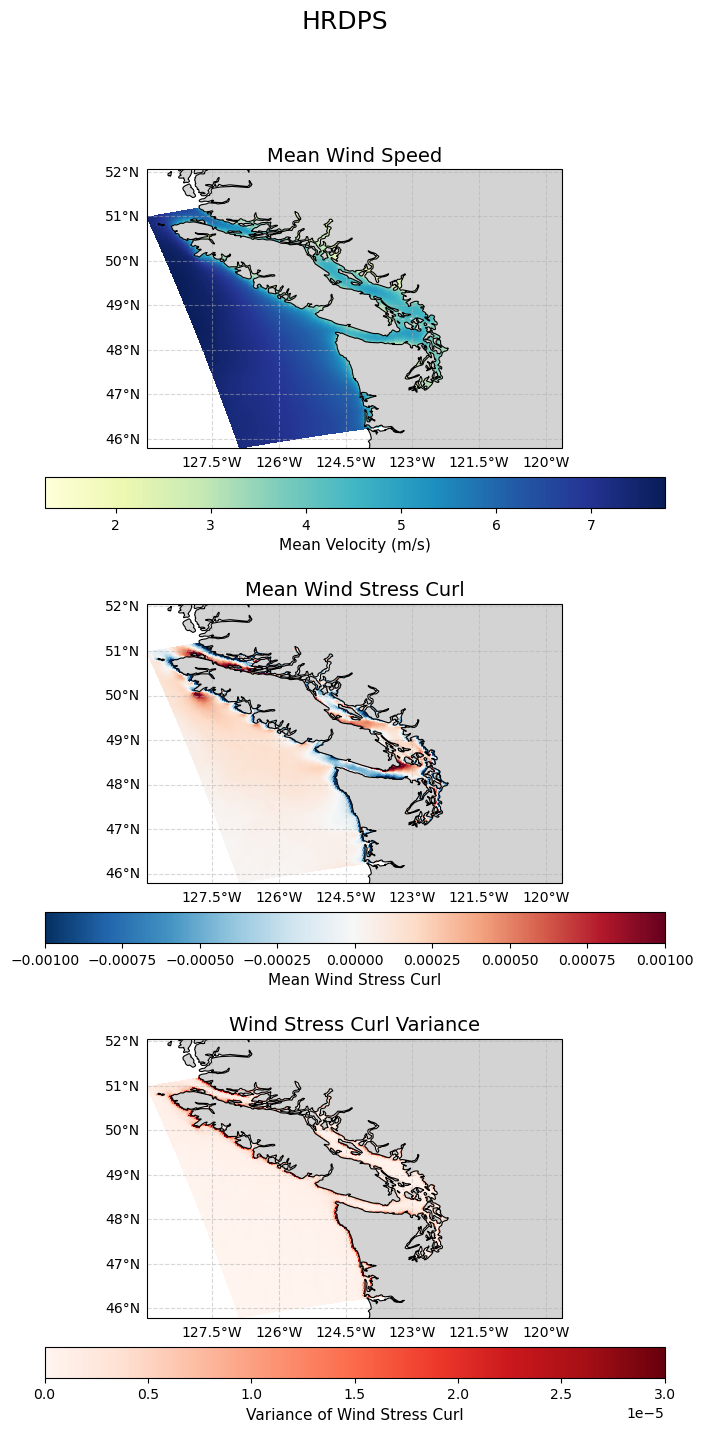

In [14]:

# visualization
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 16), subplot_kw={'projection': proj})

# map
def setup_map(ax):
    
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    
    # grid
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

# mean velocity
ax1 = axes[0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon, lat, vel, transform=proj, cmap='YlGnBu', shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Mean Velocity (m/s)', fontsize=11)
ax1.set_title('Mean Wind Speed', fontsize=14)

# mean wind stress curl
ax2 = axes[1]
setup_map(ax2)
vmax_curl = 0.001
pcm2 = ax2.pcolormesh(lon, lat, curl, transform=proj, cmap='RdBu_r', 
                      vmin=-vmax_curl, vmax=vmax_curl, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Mean Wind Stress Curl', fontsize=11)
ax2.set_title('Mean Wind Stress Curl', fontsize=14)

# variance of wind stress curl
ax3 = axes[2]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon, lat, var_curl, transform=proj, cmap='Reds',vmin=0,vmax=0.00003, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Variance of Wind Stress Curl', fontsize=11)
ax3.set_title('Wind Stress Curl Variance', fontsize=14)

plt.suptitle('HRDPS', fontsize=18)
plt.show()

### Coarsened HRDPS

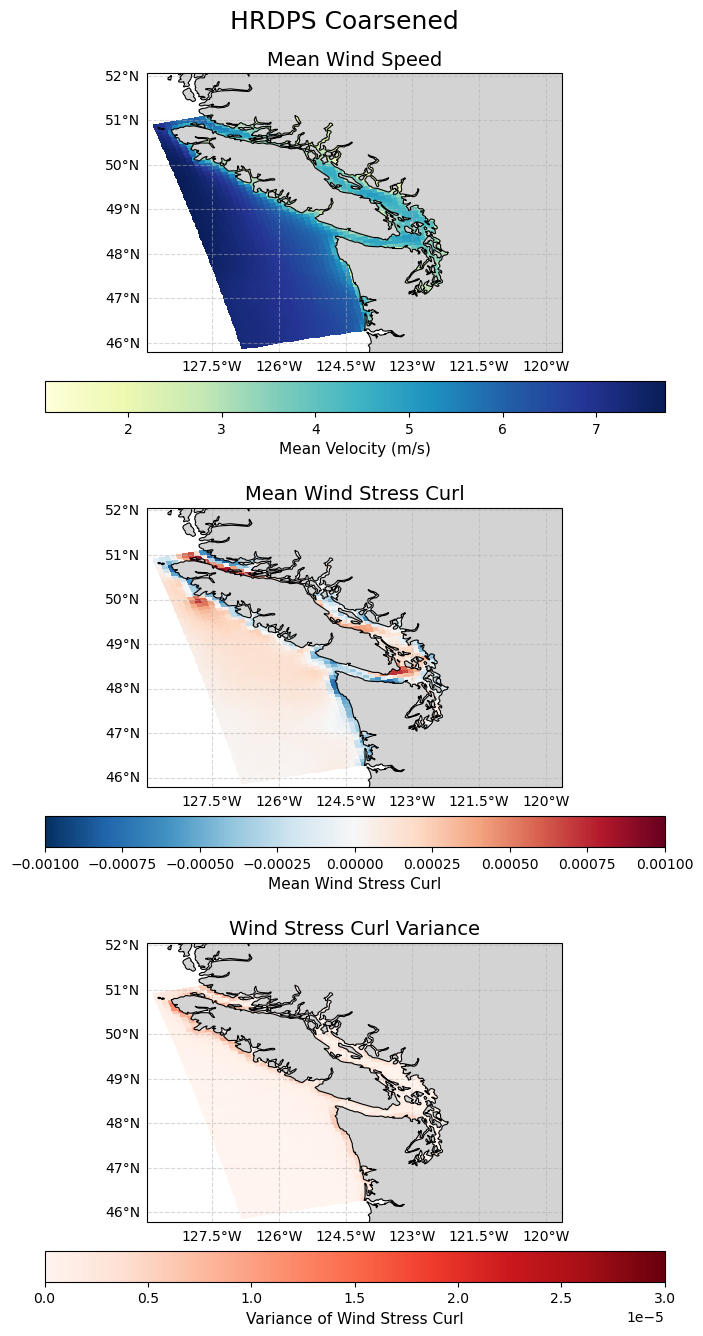

In [15]:
# HRDPS Coarsened 

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

path_hrdps_coarsened='hrdps_coarsened_2018_wind_and_curl.nc'

ds_hrdps_coarsened=xr.open_dataset(path_hrdps_coarsened)

trim_n = 2

ds_coarsened_trimmed = ds_hrdps_coarsened.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))

lon_c = ds_coarsened_trimmed.nav_lon.values
lat_c = ds_coarsened_trimmed.nav_lat.values
vel_c = ds_coarsened_trimmed.mean_velocity.values
curl_c = ds_coarsened_trimmed.mean_ws_curl.values
var_curl_c = ds_coarsened_trimmed.var_ws_curl.values

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 16), subplot_kw={'projection': proj})

def setup_map(ax):
    # 这里使用的是全局的 lon_min, lon_max, lat_min, lat_max
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

# mean velocity
ax1 = axes[0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon_c, lat_c, vel_c, transform=proj, cmap='YlGnBu', shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Mean Velocity (m/s)', fontsize=11)
ax1.set_title('Mean Wind Speed', fontsize=14)

# mean wind stress curl
ax2 = axes[1]
setup_map(ax2)
pcm2 = ax2.pcolormesh(lon_c, lat_c, curl_c, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Mean Wind Stress Curl', fontsize=11)
ax2.set_title('Mean Wind Stress Curl', fontsize=14)

# variance of wind stress curl
ax3 = axes[2]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon_c, lat_c, var_curl_c, transform=proj, cmap='Reds',
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Variance of Wind Stress Curl', fontsize=11)
ax3.set_title('Wind Stress Curl Variance', fontsize=14)

plt.suptitle('HRDPS Coarsened', fontsize=18, y=0.92)
plt.show()

In [7]:
nan_lon = int(ds_hrdps_coarsened.nav_lon.isnull().sum())
nan_lat = int(ds_hrdps_coarsened.nav_lat.isnull().sum())
print(f"[坐标] nav_lon 中的 NaN 数量: {nan_lon}")
print(f"[坐标] nav_lat 中的 NaN 数量: {nan_lat}")

[坐标] nav_lon 中的 NaN 数量: 0
[坐标] nav_lat 中的 NaN 数量: 0


In [18]:
print(ds_coarsened_trimmed)

<xarray.Dataset> Size: 105kB
Dimensions:        (y: 62, x: 60)
Coordinates:
  * x              (x) float64 480B 2.375e+04 3.375e+04 ... 6.038e+05 6.138e+05
  * y              (y) float64 496B 2.375e+04 3.375e+04 ... 6.238e+05 6.338e+05
    time_counter   datetime64[ns] 8B ...
Data variables:
    mean_velocity  (y, x) float32 15kB 7.233 7.21 7.189 7.17 ... 1.652 1.7 1.765
    mean_ws_curl   (y, x) float32 15kB 1.697e-05 1.893e-05 ... 2.267e-05
    var_ws_curl    (y, x) float32 15kB 2.07e-07 2.117e-07 ... 2.866e-08
    nav_lat        (y, x) float64 30kB 45.9 45.92 45.94 ... 51.88 51.89 51.91
    nav_lon        (y, x) float64 30kB 233.2 233.3 233.5 ... 238.9 239.1 239.2


### CaSR

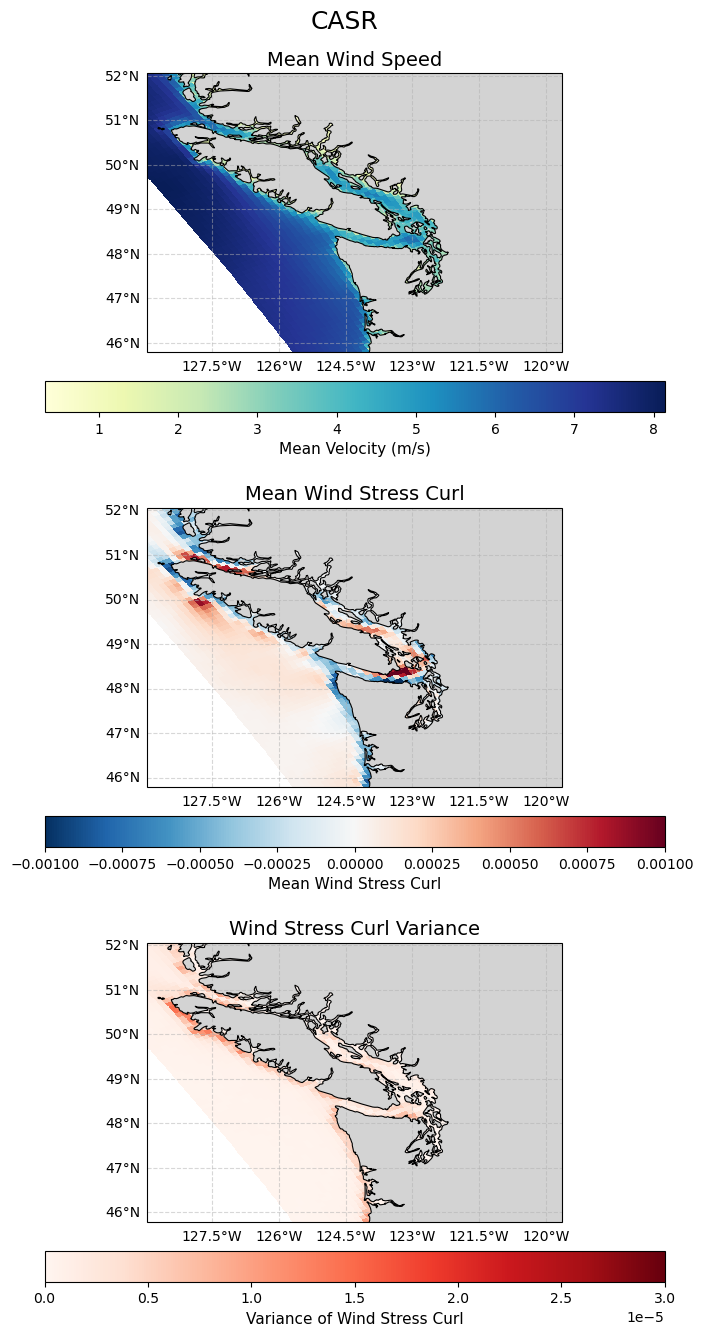

In [12]:

# CASR 

trim_n = 2
ds_casr_trimmed = ds_casr.isel(rlon=slice(trim_n, -trim_n), rlat=slice(trim_n, -trim_n))

lon_casr = ds_casr_trimmed.lon.values
lat_casr = ds_casr_trimmed.lat.values
vel_casr = ds_casr_trimmed.mean_velocity.values
curl_casr = ds_casr_trimmed.mean_ws_casr.values
var_curl_casr = ds_casr_trimmed.var_ws_casr.values

# 【修改点】同样删除了重新计算边界的代码

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 16), subplot_kw={'projection': proj})

def setup_map(ax):
    # 这里使用的是全局的 lon_min, lon_max, lat_min, lat_max
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

# mean velocity
ax1 = axes[0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon_casr, lat_casr, vel_casr, transform=proj, cmap='YlGnBu', shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Mean Velocity (m/s)', fontsize=11)
ax1.set_title('Mean Wind Speed', fontsize=14)

# mean wind stress curl
ax2 = axes[1]
setup_map(ax2)
pcm2 = ax2.pcolormesh(lon_casr, lat_casr, curl_casr, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Mean Wind Stress Curl', fontsize=11)
ax2.set_title('Mean Wind Stress Curl', fontsize=14)

# variance of wind stress curl
ax3 = axes[2]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon_casr, lat_casr, var_curl_casr, transform=proj, cmap='Reds',
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Variance of Wind Stress Curl', fontsize=11)
ax3.set_title('Wind Stress Curl Variance', fontsize=14)

plt.suptitle('CASR', fontsize=18, y=0.92)
plt.show()

## Whole Region Compare (Outdated)

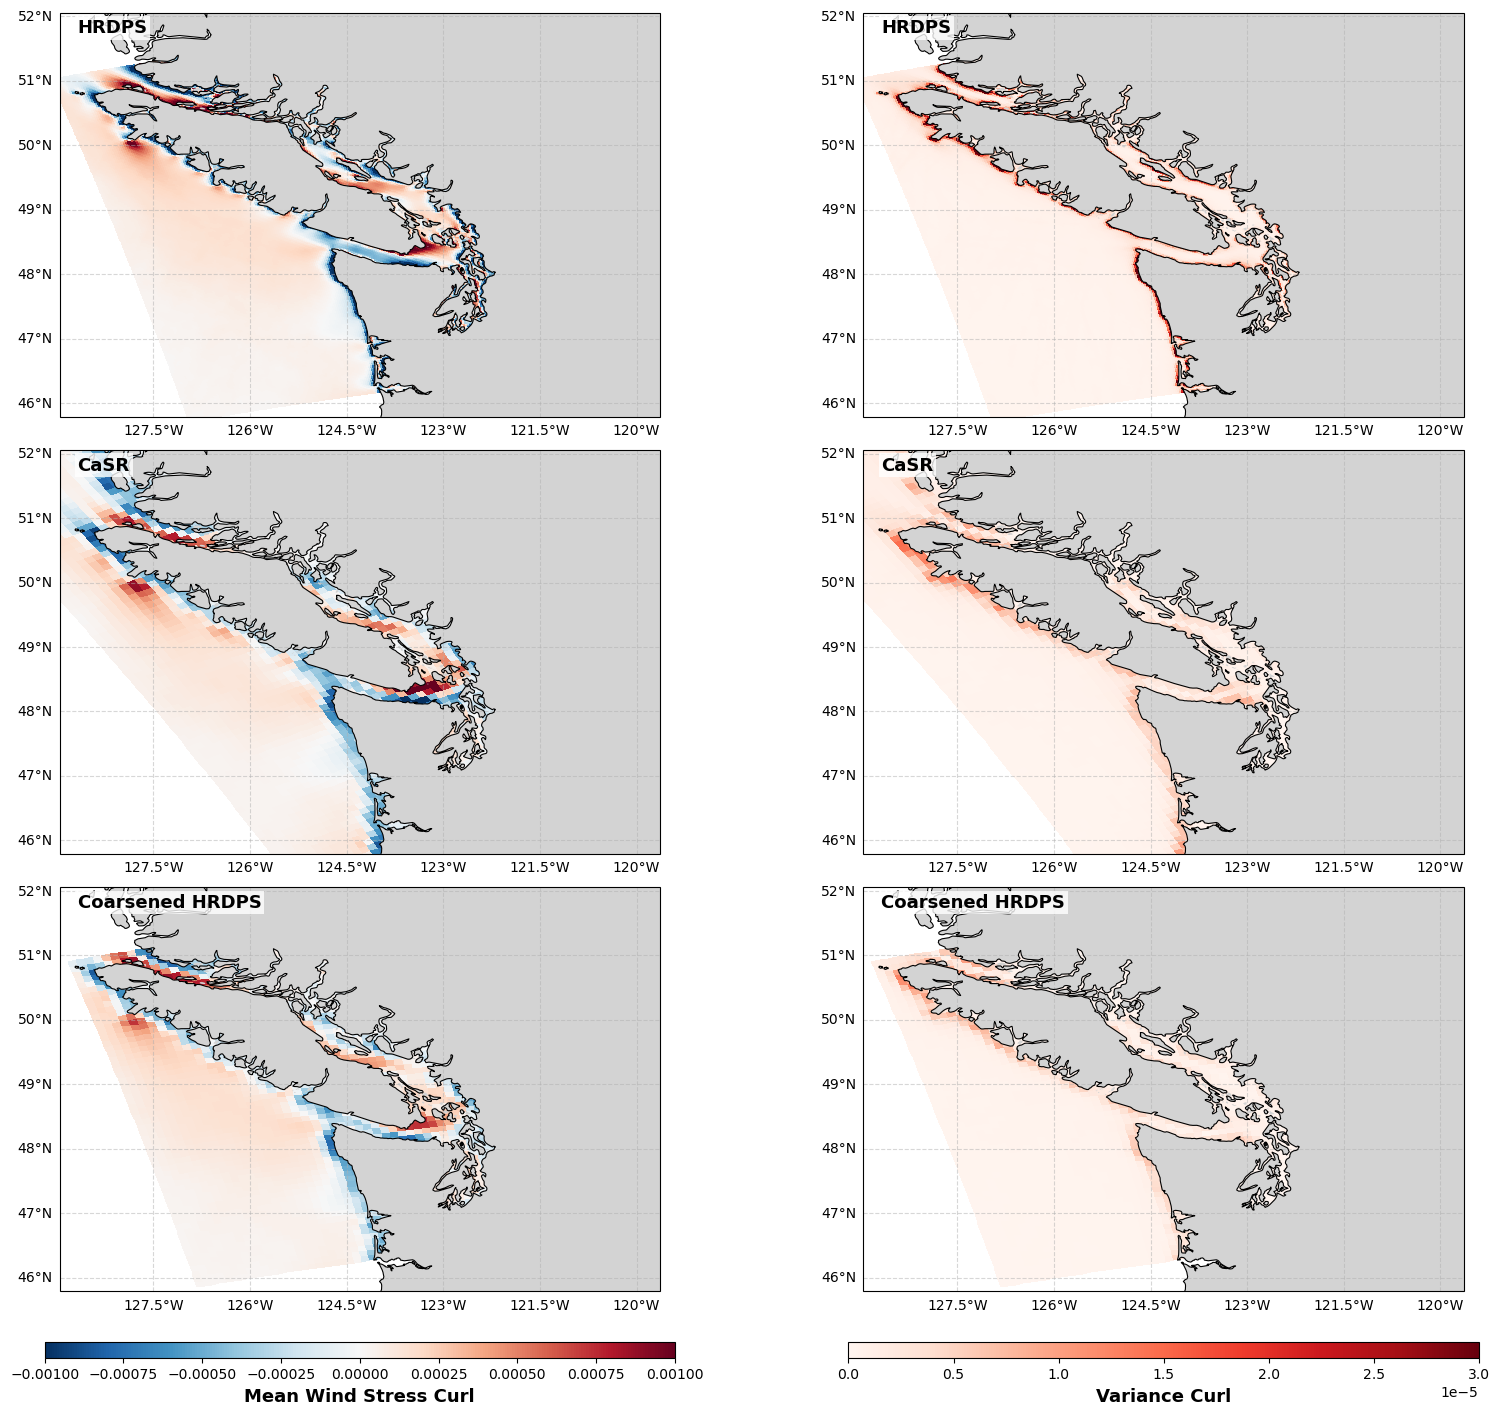

In [25]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


trim_n = 2

# HRDPS 
ds_h_trim = ds_hrdps.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))
# 如果你的原始 HRDPS 坐标也有 NaN 报错，可以在这里加上 .ffill().bfill()
lon_h = ds_h_trim.nav_lon.values
lat_h = ds_h_trim.nav_lat.values
curl_h = ds_h_trim.mean_ws_curl.values
var_h = ds_h_trim.var_ws_curl.values

# CASR 
ds_c_trim = ds_casr.isel(rlon=slice(trim_n, -trim_n), rlat=slice(trim_n, -trim_n))
lon_c = ds_c_trim.lon.values
lat_c = ds_c_trim.lat.values
curl_c = ds_c_trim.mean_ws_casr.values
var_c = ds_c_trim.var_ws_casr.values

# Coarsened HRDPS


'''mean_velocity  (y, x) float32 15kB 7.233 7.21 7.189 7.17 ... 1.652 1.7 1.765
    mean_ws_curl   (y, x) float32 15kB 1.697e-05 1.893e-05 ... 2.267e-05
    var_ws_curl    (y, x) float32 15kB 2.07e-07 2.117e-07 ... 2.866e-08
    nav_lat        (y, x) float64 30kB 45.9 45.92 45.94 ... 51.88 51.89 51.91
    nav_lon        (y, x) float64 30kB 233.2 233.3 233.5 ... 238.9 239.1 239.2'''

ds_r_trim = ds_hrdps_coarsened.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))
lon_r = ds_r_trim.nav_lon.values
lat_r = ds_r_trim.nav_lat.values
curl_r = ds_r_trim.mean_ws_curl.values
var_r = ds_r_trim.var_ws_curl.values

# 复用全局显示范围 (假设之前已经计算好，如果没有，请确保这里有具体数值)
# 例如: lon_min, lon_max, lat_min, lat_max = -65.0, -50.0, 40.0, 55.0

# visualization

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14), subplot_kw={'projection': proj}, layout='constrained')

# 统一地图设置的辅助函数
def setup_map(ax):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

#  HRDPS Mean Curl
ax1 = axes[0, 0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon_h, lat_h, curl_h, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
# cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
# cb1.set_label('Wind Stress Curl', fontsize=11)
# ax1.set_title('HRDPS: Mean Wind Stress Curl', fontsize=14, fontweight='bold')
ax1.text(0.03, 0.95, 'HRDPS', transform=ax1.transAxes, fontsize=13, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), 
         zorder=10)
# HRDPS - Variance
ax2 = axes[0, 1]
setup_map(ax2)
pcm2 = ax2.pcolormesh(lon_h, lat_h, var_h, transform=proj, cmap='Reds', 
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
# cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
# cb2.set_label('Variance of Curl', fontsize=11)
# ax2.set_title('HRDPS: Wind Stress Curl Variance', fontsize=14, fontweight='bold')
ax2.text(0.03, 0.95, 'HRDPS', transform=ax2.transAxes, fontsize=13, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), 
         zorder=10)

# CASR
# CASR Mean Curl
ax3 = axes[1, 0]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon_c, lat_c, curl_c, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
# cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
# cb3.set_label('Wind Stress Curl', fontsize=11)
# ax3.set_title('CASR: Mean Wind Stress Curl', fontsize=14, fontweight='bold')
ax3.text(0.03, 0.95, 'CaSR', transform=ax3.transAxes, fontsize=13, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), 
         zorder=10)

# CASR Variance
ax4 = axes[1, 1]
setup_map(ax4)
pcm4 = ax4.pcolormesh(lon_c, lat_c, var_c, transform=proj, cmap='Reds', 
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
# cb4 = plt.colorbar(pcm4, ax=ax4, orientation='horizontal', pad=0.08)
# cb4.set_label('Variance of Curl', fontsize=11)
# ax4.set_title('CASR: Wind Stress Curl Variance', fontsize=14, fontweight='bold')
ax4.text(0.03, 0.95, 'CaSR', transform=ax4.transAxes, fontsize=13, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), 
         zorder=10)

# Coarsened HRDPS
# Coarsened HRDPS Mean Curl
ax5 = axes[2, 0]
setup_map(ax5)
pcm5 = ax5.pcolormesh(lon_r, lat_r, curl_r, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
# cb5 = plt.colorbar(pcm5, ax=ax5, orientation='horizontal', pad=0.08)
# cb5.set_label('Wind Stress Curl', fontsize=11)
# ax5.set_title('Coarsened HRDPS: Mean Wind Stress Curl', fontsize=14, fontweight='bold')
ax5.text(0.03, 0.95, 'Coarsened HRDPS', transform=ax5.transAxes, fontsize=13, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), 
         zorder=10)

# Coarsened HRDPS Variance
ax6 = axes[2, 1]
setup_map(ax6)
pcm6 = ax6.pcolormesh(lon_r, lat_r, var_r, transform=proj, cmap='Reds', 
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
# cb6 = plt.colorbar(pcm6, ax=ax6, orientation='horizontal', pad=0.08)
# cb6.set_label('Variance of Curl', fontsize=11)
# ax6.set_title('Coarsened HRDPS: Wind Stress Curl Variance', fontsize=14, fontweight='bold')
ax6.text(0.03, 0.95, 'Coarsened HRDPS', transform=ax6.transAxes, fontsize=13, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), 
         zorder=10)

# 调整主标题和子图间距
#plt.suptitle('Comparison of Wind Stress Dynamics: HRDPS vs CASR', fontsize=18, y=0.95)
#plt.subplots_adjust(hspace=0.2, wspace=0.1)

cb_mean_all=fig.colorbar(pcm1, ax=axes[:,0],orientation='horizontal', aspect=40, shrink=0.8, pad=0.02)
cb_mean_all.set_label('Mean Wind Stress Curl', fontsize=13, fontweight='bold')
cb_var_all=fig.colorbar(pcm2, ax=axes[:,1],orientation='horizontal', aspect=40, shrink=0.8, pad=0.02)
cb_var_all.set_label('Variance Curl', fontsize=13, fontweight='bold')

plt.show()

## Salish Sea Compare (Outdated)

Here we pick some points inside Salish Sea based on bathymetry data to generate the scatter plots of curl mean and curl variance between models.



In [28]:
import xarray as xr

path_bathy='/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea2.nc'

ds_bathy=xr.open_dataset(path_bathy)

print(ds_bathy)


<xarray.Dataset> Size: 9MB
Dimensions:     (y: 898, x: 398)
Dimensions without coordinates: y, x
Data variables:
    nav_lon     (y, x) float64 3MB ...
    nav_lat     (y, x) float64 3MB ...
    Bathymetry  (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        Salish Sea NEMO Bathymetry
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    references:   https://bitbucket.org/salishsea/nemo-forcing/src/tip/grid/b...
    comment:      Based on 1_bathymetry_seagrid_WestCoast.nc file from 2-Oct-...
    source:       \nhttps://bitbucket.org/salishsea/tools/src/tip/bathymetry/...
    history:      \n[2013-10-30 13:18] Created netCDF4 zlib=True dataset.\n[2...


In [1]:
# Scatter Plot within the Salish Sea

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# 

# Matching lon lim
def normalize_lon(lon):
    return (lon + 180) % 360 - 180

# paths
path_casr = 'casr_2018_wind_and_curl.nc'
path_hrdps = 'hrdps_2018_wind_and_curl.nc'
path_hrdps_coarsened = 'hrdps_coarsened_2018_wind_and_curl.nc'
path_bathy = '/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea2.nc'

# load datasets

ds_casr = xr.open_dataset(path_casr)
ds_hrdps = xr.open_dataset(path_hrdps)
ds_hrdps_coarsened = xr.open_dataset(path_hrdps_coarsened)
ds_bathy = xr.open_dataset(path_bathy)

# valid coordinates bathy>0

bathy_vals = ds_bathy['Bathymetry'].values[::8, ::8]
mask_water = bathy_vals > 0

nav_lon_sub = ds_bathy['nav_lon'].values[::8, ::8]
nav_lat_sub = ds_bathy['nav_lat'].values[::8, ::8]

water_lon = normalize_lon(nav_lon_sub[mask_water])
water_lat = nav_lat_sub[mask_water]

target_coords = np.column_stack((water_lon, water_lat))


# match the points
def get_model_matched_data(ds, lon_var, lat_var, mean_var, var_var, target_coords):
    
    model_lon = normalize_lon(ds[lon_var].values.flatten())
    model_lat = ds[lat_var].values.flatten()
    
    model_mean = ds[mean_var].values.flatten()
    model_var  = ds[var_var].values.flatten()
    
    # get rid of nan
    valid_coord_mask = ~(np.isnan(model_lon) | np.isnan(model_lat))
    model_lon = model_lon[valid_coord_mask]
    model_lat = model_lat[valid_coord_mask]
    model_mean = model_mean[valid_coord_mask]
    model_var = model_var[valid_coord_mask]
    
    # 
    tree = cKDTree(np.column_stack((model_lon, model_lat)))
    
    distances, indices = tree.query(target_coords)
    
    # extract data
    matched_mean = model_mean[indices]
    matched_var  = model_var[indices]
    
    return matched_mean, matched_var

# ================= 5. 进行坐标匹配并提取数据 =================

hrdps_mean, hrdps_var = get_model_matched_data(
    ds_hrdps, 'nav_lon', 'nav_lat', 'mean_ws_curl', 'var_ws_curl', target_coords
)


casr_mean, casr_var = get_model_matched_data(
    ds_casr, 'lon', 'lat', 'mean_ws_casr', 'var_ws_casr', target_coords
)


hrdps_c_mean, hrdps_c_var = get_model_matched_data(
    ds_hrdps_coarsened, 'nav_lon', 'nav_lat', 'mean_ws_curl', 'var_ws_curl', target_coords
)


<function matplotlib.pyplot.show(close=None, block=None)>

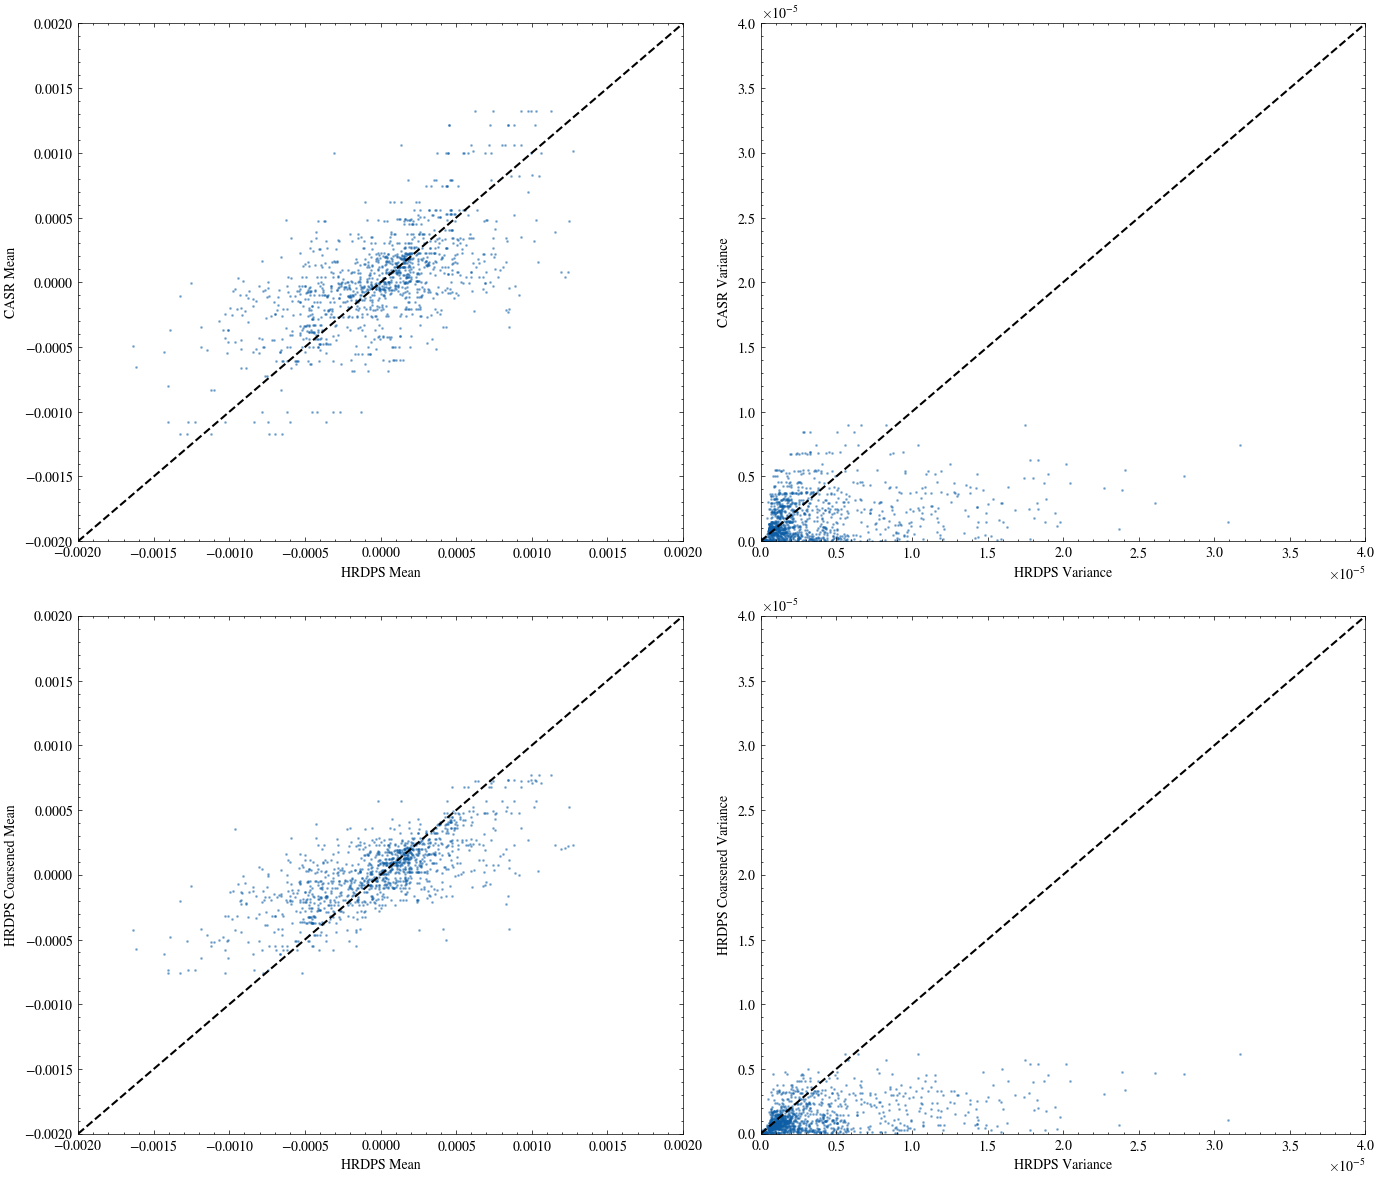

In [14]:

# scatter plot

# try our new SciencePlots

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_kwargs = {'s': 1, 'alpha': 0.4, 'color': 'C0'}
diag_kwargs = {'color': 'k', 'linestyle': '--', 'linewidth': 1.5}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  
        np.max([ax.get_xlim(), ax.get_ylim()]),  
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

axes[0, 0].scatter(hrdps_mean, casr_mean, **scatter_kwargs)
axes[0, 0].set_xlim([-0.002,0.002])
axes[0, 0].set_ylim([-0.002,0.002])
add_diagonal_line(axes[0, 0])
# axes[0, 0].set_title('Mean Wind Stress Curl: CASR vs HRDPS')
axes[0, 0].set_xlabel('HRDPS Mean')
axes[0, 0].set_ylabel('CASR Mean')

axes[0, 1].scatter(hrdps_var, casr_var, **scatter_kwargs)
axes[0, 1].set_xlim([0,4e-5])
axes[0, 1].set_ylim([0,4e-5])
add_diagonal_line(axes[0, 1])
# axes[0, 1].set_title('Variance of Wind Stress Curl: CASR vs HRDPS')
axes[0, 1].set_xlabel('HRDPS Variance')
axes[0, 1].set_ylabel('CASR Variance')

axes[1, 0].scatter(hrdps_mean, hrdps_c_mean, **scatter_kwargs)
axes[1, 0].set_xlim([-0.002,0.002])
axes[1, 0].set_ylim([-0.002,0.002])
add_diagonal_line(axes[1, 0])
# axes[1, 0].set_title('Mean Wind Stress Curl: Coarsened vs HRDPS')
axes[1, 0].set_xlabel('HRDPS Mean')
axes[1, 0].set_ylabel('HRDPS Coarsened Mean')

axes[1, 1].scatter(hrdps_var, hrdps_c_var, **scatter_kwargs)
axes[1, 1].set_xlim([0,4e-5])
axes[1, 1].set_ylim([0,4e-5])
add_diagonal_line(axes[1, 1])
# axes[1, 1].set_title('Variance of Wind Stress Curl: Coarsened vs HRDPS')
axes[1, 1].set_xlabel('HRDPS Variance')
axes[1, 1].set_ylabel('HRDPS Coarsened Variance')

plt.tight_layout()
plt.show

Note that there are a few `rdps` and `r` in the codes, which in fact refer to `HRDPS coarsened`. It was a mistake, but doesn't impact the results.

## Wind speed scatter within the Salish sea

### Constructing data

In [3]:
# Scatter Plot within the Salish Sea

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Matching lon lim
def normalize_lon(lon):
    return (lon + 180) % 360 - 180

# paths
path_casr = 'casr_2018_wind_mean.nc'
path_hrdps = 'hrdps_2018_wind_mean.nc'
path_hrdps_coarsened = 'hrdps_coarsened_2018_wind_mean.nc'
path_hrdps_subsampled = 'hrdps_subsampled_2018_wind_mean.nc'
path_bathy = '/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea2.nc'

# load datasets
ds_casr = xr.open_dataset(path_casr)
ds_hrdps = xr.open_dataset(path_hrdps)
ds_hrdps_coarsened = xr.open_dataset(path_hrdps_coarsened)
ds_hrdps_subsampled = xr.open_dataset(path_hrdps_subsampled)
ds_bathy = xr.open_dataset(path_bathy)

# valid coordinates bathy>0
bathy_vals = ds_bathy['Bathymetry'].values[::8, ::8]
mask_water = bathy_vals > 0

nav_lon_sub = ds_bathy['nav_lon'].values[::8, ::8]
nav_lat_sub = ds_bathy['nav_lat'].values[::8, ::8]

water_lon = normalize_lon(nav_lon_sub[mask_water])
water_lat = nav_lat_sub[mask_water]

target_coords = np.column_stack((water_lon, water_lat))


def get_model_matched_data(ds, lon_var, lat_var, target_coords, var_names):
    """
    ds: xarray Dataset
    lon_var: longitude 变量名
    lat_var: latitude 变量名
    target_coords: 目标坐标数组
    var_names: 需要提取的变量名列表，如 ['mean_velocity', 'mean_velocity_squared']
    """
    model_lon = normalize_lon(ds[lon_var].values.flatten())
    model_lat = ds[lat_var].values.flatten()
    
    # get rid of nan in coordinates
    valid_coord_mask = ~(np.isnan(model_lon) | np.isnan(model_lat))
    model_lon = model_lon[valid_coord_mask]
    model_lat = model_lat[valid_coord_mask]
    
    # Build tree and query only ONCE
    tree = cKDTree(np.column_stack((model_lon, model_lat)))
    distances, indices = tree.query(target_coords)
    
    # extract all requested variables
    matched_results = []
    for var in var_names:
        model_var = ds[var].values.flatten()
        # 应用相同的空间 mask
        model_var = model_var[valid_coord_mask]
        # 根据 KDTree 的结果提取数据
        matched_results.append(model_var[indices])
        
    # 如果只请求了一个变量，直接返回该变量；如果请求了多个，返回元组便于解包
    if len(matched_results) == 1:
        return matched_results[0]
    else:
        return tuple(matched_results)



# coordinate matching

# 提取 HRDPS 的三个变量
hrdps_absolute_mean, hrdps_squared_mean, hrdps_cubed_mean, hrdps_wsc_mean = get_model_matched_data(
    ds_hrdps, 'nav_lon', 'nav_lat', target_coords, 
    ['mean_velocity', 'mean_velocity_squared', 'mean_velocity_cubed','mean_ws_curl']
)

# 提取 CASR 的平均值
casr_absolute_mean, casr_squared_mean, casr_cubed_mean, casr_wsc_mean = get_model_matched_data(
    ds_casr, 'lon', 'lat', target_coords, 
    ['mean_velocity', 'mean_velocity_squared', 'mean_velocity_cubed','mean_ws_casr']
)

# 提取 Coarsened HRDPS 的变量
hrdps_c_absolute_mean, hrdps_c_squared_mean, hrdps_c_cubed_mean, hrdps_c_wsc_mean = get_model_matched_data(
    ds_hrdps_coarsened, 'nav_lon', 'nav_lat', target_coords, 
    ['mean_velocity', 'mean_velocity_squared', 'mean_velocity_cubed','mean_ws_curl']
)

# 提取 Subsampled HRDPS 的变量
hrdps_s_absolute_mean, hrdps_s_squared_mean, hrdps_s_cubed_mean, hrdps_s_wsc_mean = get_model_matched_data(
    ds_hrdps_subsampled, 'nav_lon', 'nav_lat', target_coords, 
    ['mean_velocity', 'mean_velocity_squared', 'mean_velocity_cubed','mean_ws_curl']
)

### Scatter plot

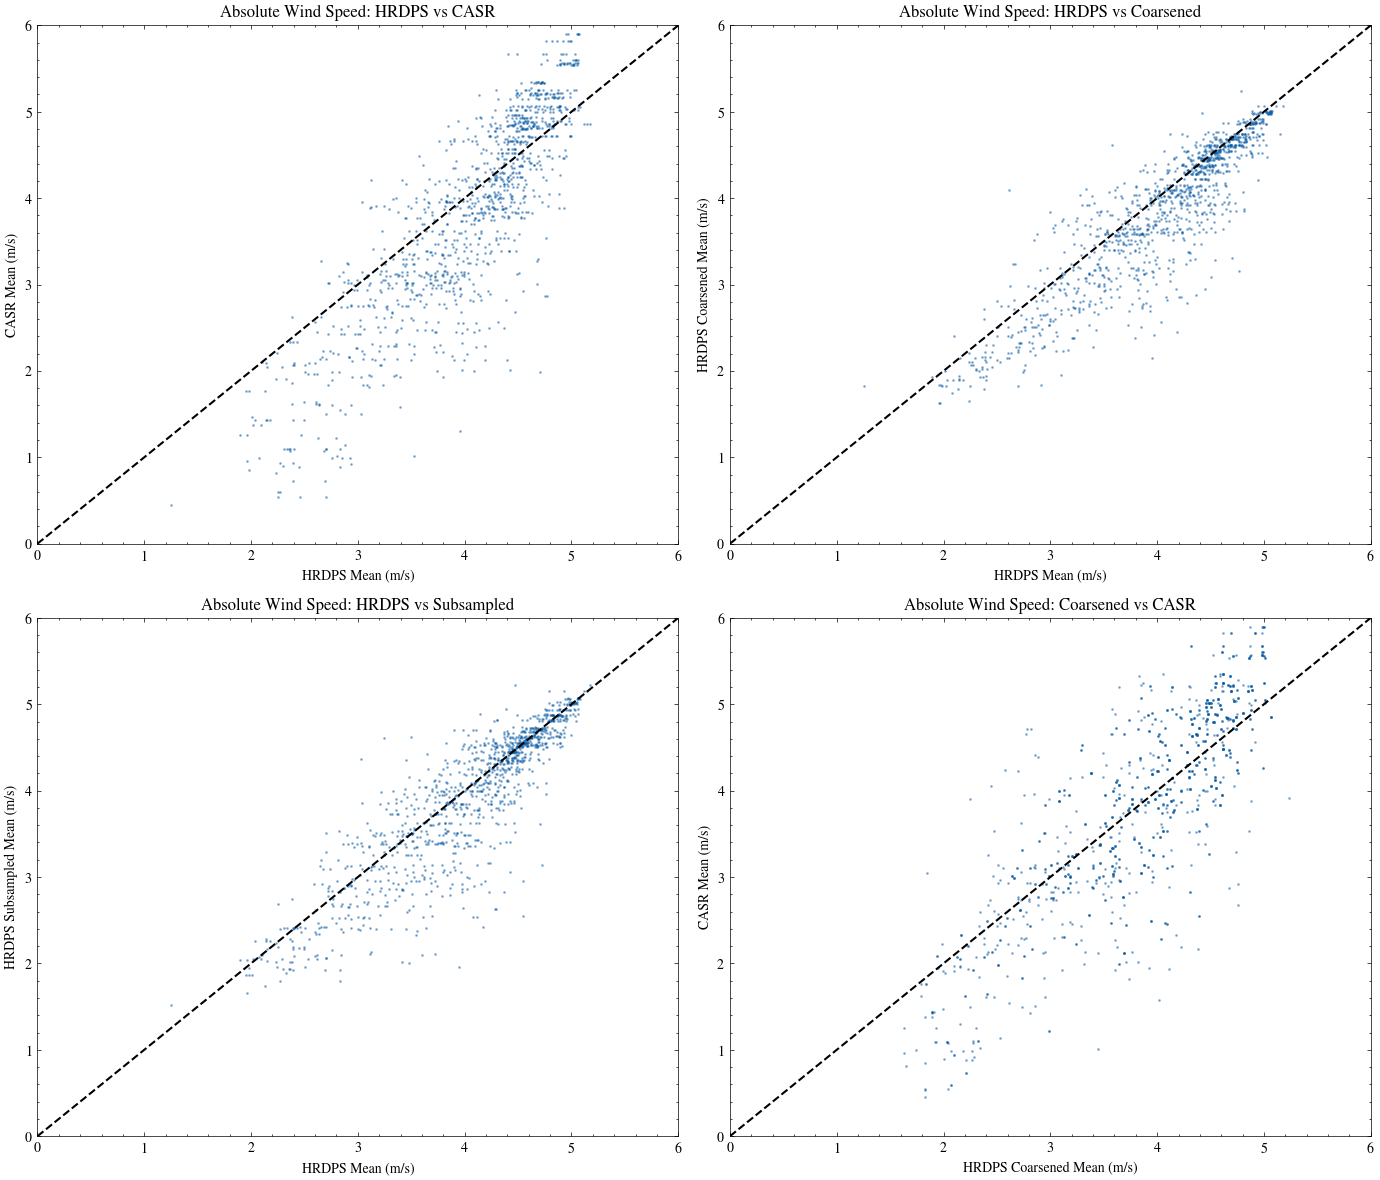

In [18]:
# Scatter Plot for Absolute Wind Speed Mean

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_kwargs = {'s': 1, 'alpha': 0.4, 'color': 'C0'}
diag_kwargs = {'color': 'k', 'linestyle': '--', 'linewidth': 1.5}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  
        np.max([ax.get_xlim(), ax.get_ylim()]),  
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)


v_lims = [0, 6] 

# 1. Top-Left: 原版 HRDPS vs CASR
axes[0, 0].scatter(hrdps_absolute_mean, casr_absolute_mean, **scatter_kwargs)
axes[0, 0].set_xlim(v_lims)
axes[0, 0].set_ylim(v_lims)
add_diagonal_line(axes[0, 0])
axes[0, 0].set_title('Absolute Wind Speed: HRDPS vs CASR')
axes[0, 0].set_xlabel('HRDPS Mean (m/s)')
axes[0, 0].set_ylabel('CASR Mean (m/s)')

# 2. Top-Right: 原版 HRDPS vs Coarsened HRDPS
axes[0, 1].scatter(hrdps_absolute_mean, hrdps_c_absolute_mean, **scatter_kwargs)
axes[0, 1].set_xlim(v_lims)
axes[0, 1].set_ylim(v_lims)
add_diagonal_line(axes[0, 1])
axes[0, 1].set_title('Absolute Wind Speed: HRDPS vs Coarsened')
axes[0, 1].set_xlabel('HRDPS Mean (m/s)')
axes[0, 1].set_ylabel('HRDPS Coarsened Mean (m/s)')

# 3. Bottom-Left: 原版 HRDPS vs Subsampled HRDPS
axes[1, 0].scatter(hrdps_absolute_mean, hrdps_s_absolute_mean, **scatter_kwargs)
axes[1, 0].set_xlim(v_lims)
axes[1, 0].set_ylim(v_lims)
add_diagonal_line(axes[1, 0])
axes[1, 0].set_title('Absolute Wind Speed: HRDPS vs Subsampled')
axes[1, 0].set_xlabel('HRDPS Mean (m/s)')
axes[1, 0].set_ylabel('HRDPS Subsampled Mean (m/s)')

# 4. Bottom-Right: Coarsened HRDPS vs CASR (对比两个分辨率相近的模型)
axes[1, 1].scatter(hrdps_c_absolute_mean, casr_absolute_mean, **scatter_kwargs)
axes[1, 1].set_xlim(v_lims)
axes[1, 1].set_ylim(v_lims)
add_diagonal_line(axes[1, 1])
axes[1, 1].set_title('Absolute Wind Speed: Coarsened vs CASR')
axes[1, 1].set_xlabel('HRDPS Coarsened Mean (m/s)')
axes[1, 1].set_ylabel('CASR Mean (m/s)')

plt.tight_layout()
plt.show()

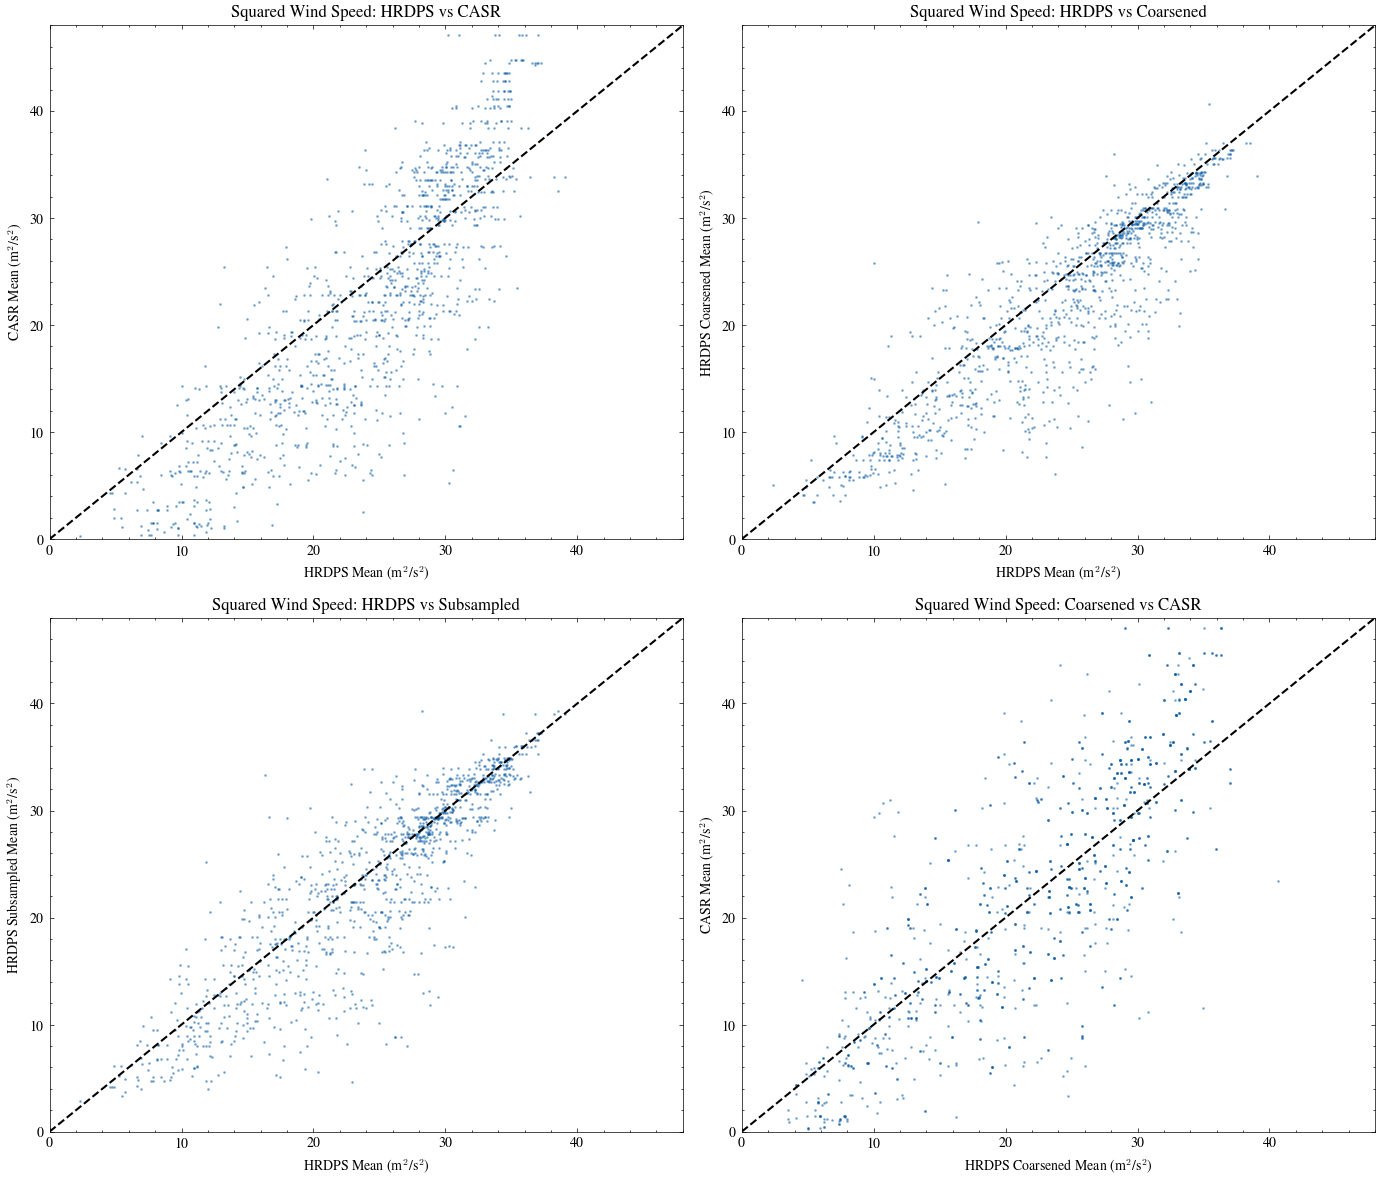

In [19]:
# Scatter Plot for squared Wind Speed Mean

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_kwargs = {'s': 1, 'alpha': 0.4, 'color': 'C0'}
diag_kwargs = {'color': 'k', 'linestyle': '--', 'linewidth': 1.5}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  
        np.max([ax.get_xlim(), ax.get_ylim()]),  
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)


v_lims = [0, 48] 

# 1. Top-Left: 原版 HRDPS vs CASR
axes[0, 0].scatter(hrdps_squared_mean, casr_squared_mean, **scatter_kwargs)
axes[0, 0].set_xlim(v_lims)
axes[0, 0].set_ylim(v_lims)
add_diagonal_line(axes[0, 0])
axes[0, 0].set_title('Squared Wind Speed: HRDPS vs CASR')
axes[0, 0].set_xlabel('HRDPS Mean (m$^2$/s$^2$)')
axes[0, 0].set_ylabel('CASR Mean (m$^2$/s$^2$)')

# 2. Top-Right: 原版 HRDPS vs Coarsened HRDPS
axes[0, 1].scatter(hrdps_squared_mean, hrdps_c_squared_mean, **scatter_kwargs)
axes[0, 1].set_xlim(v_lims)
axes[0, 1].set_ylim(v_lims)
add_diagonal_line(axes[0, 1])
axes[0, 1].set_title('Squared Wind Speed: HRDPS vs Coarsened')
axes[0, 1].set_xlabel('HRDPS Mean (m$^2$/s$^2$)')
axes[0, 1].set_ylabel('HRDPS Coarsened Mean (m$^2$/s$^2$)')

# 3. Bottom-Left: 原版 HRDPS vs Subsampled HRDPS
axes[1, 0].scatter(hrdps_squared_mean, hrdps_s_squared_mean, **scatter_kwargs)
axes[1, 0].set_xlim(v_lims)
axes[1, 0].set_ylim(v_lims)
add_diagonal_line(axes[1, 0])
axes[1, 0].set_title('Squared Wind Speed: HRDPS vs Subsampled')
axes[1, 0].set_xlabel('HRDPS Mean (m$^2$/s$^2$)')
axes[1, 0].set_ylabel('HRDPS Subsampled Mean (m$^2$/s$^2$)')

# 4. Bottom-Right: Coarsened HRDPS vs CASR (对比两个分辨率相近的模型)
axes[1, 1].scatter(hrdps_c_squared_mean, casr_squared_mean, **scatter_kwargs)
axes[1, 1].set_xlim(v_lims)
axes[1, 1].set_ylim(v_lims)
add_diagonal_line(axes[1, 1])
axes[1, 1].set_title('Squared Wind Speed: Coarsened vs CASR')
axes[1, 1].set_xlabel('HRDPS Coarsened Mean (m$^2$/s$^2$)')
axes[1, 1].set_ylabel('CASR Mean (m$^2$/s$^2$)')

plt.tight_layout()
plt.show()

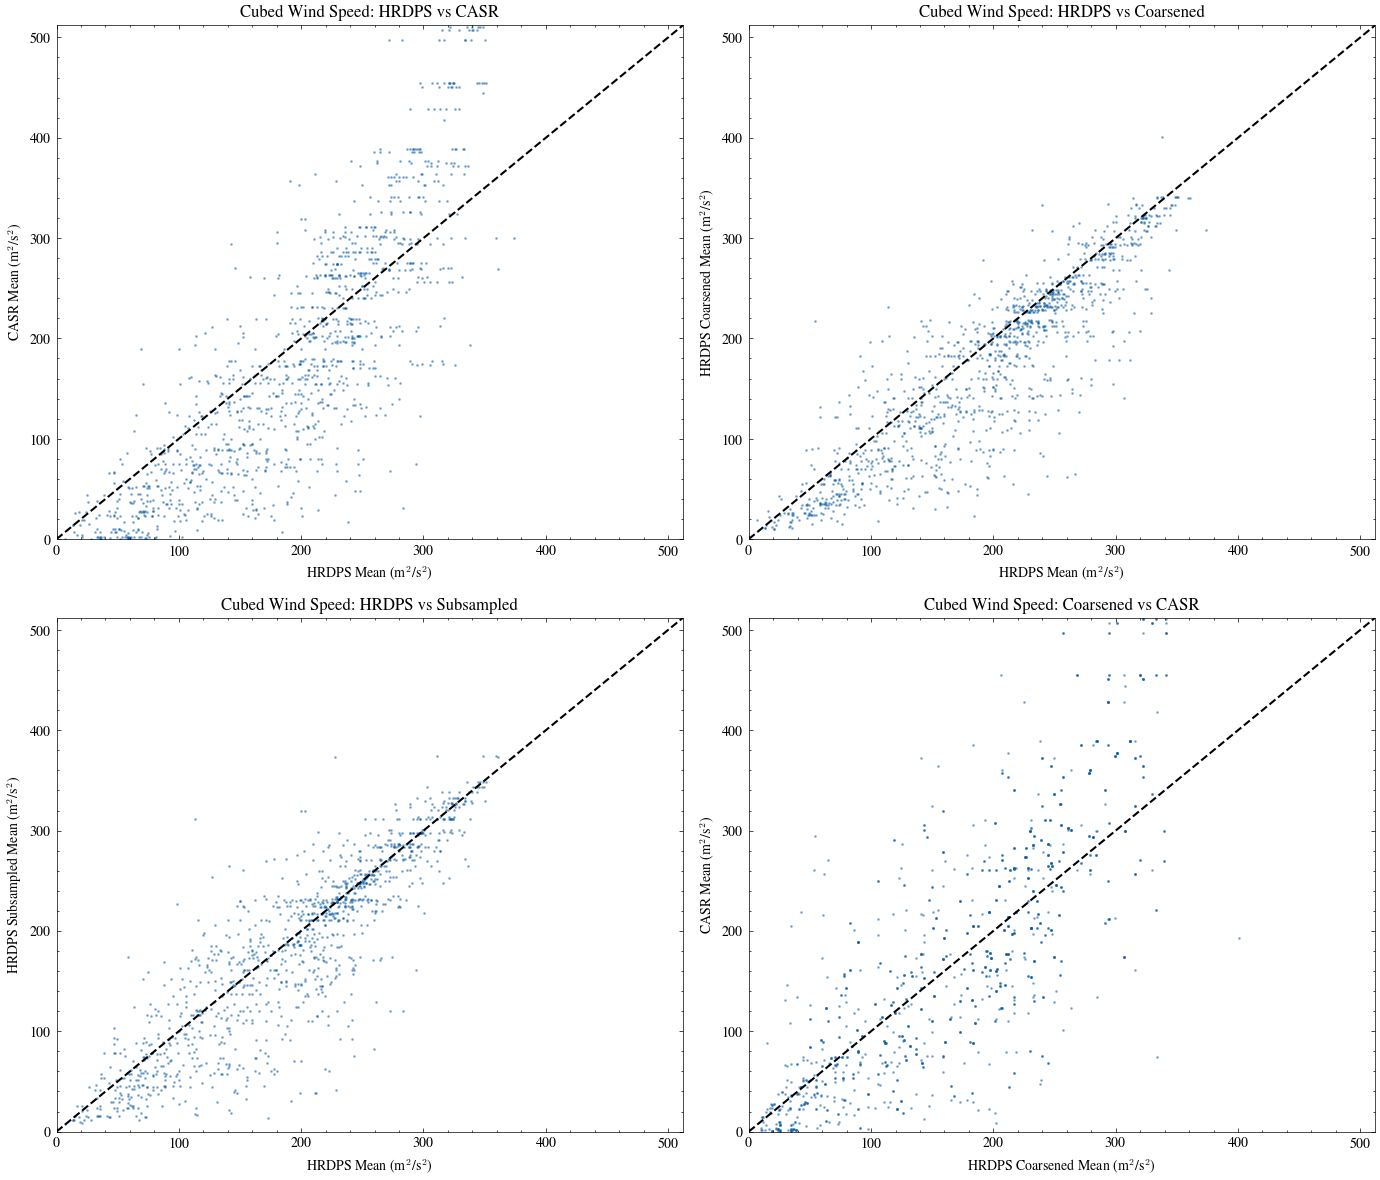

In [ ]:
# Scatter Plot for cubed Wind Speed Mean

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_kwargs = {'s': 1, 'alpha': 0.4, 'color': 'C0'}
diag_kwargs = {'color': 'k', 'linestyle': '--', 'linewidth': 1.5}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  
        np.max([ax.get_xlim(), ax.get_ylim()]),  
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)


v_lims = [0, 512] 

# Top-Left: 原版 HRDPS vs CASR
axes[0, 0].scatter(hrdps_cubed_mean, casr_cubed_mean, **scatter_kwargs)
axes[0, 0].set_xlim(v_lims)
axes[0, 0].set_ylim(v_lims)
add_diagonal_line(axes[0, 0])
axes[0, 0].set_title('Cubed Wind Speed: HRDPS vs CASR')
axes[0, 0].set_xlabel('HRDPS Mean (m$^3$/s$^3$)')
axes[0, 0].set_ylabel('CASR Mean (m$^3$/s$^3$)')

# Top-Right: 原版 HRDPS vs Coarsened HRDPS
axes[0, 1].scatter(hrdps_cubed_mean, hrdps_c_cubed_mean, **scatter_kwargs)
axes[0, 1].set_xlim(v_lims)
axes[0, 1].set_ylim(v_lims)
add_diagonal_line(axes[0, 1])
axes[0, 1].set_title('Cubed Wind Speed: HRDPS vs Coarsened')
axes[0, 1].set_xlabel('HRDPS Mean (m$^3$/s$^3$)')
axes[0, 1].set_ylabel('HRDPS Coarsened Mean (m$^2$/s$^2$)')

# Bottom-Left: 原版 HRDPS vs Subsampled HRDPS
axes[1, 0].scatter(hrdps_cubed_mean, hrdps_s_cubed_mean, **scatter_kwargs)
axes[1, 0].set_xlim(v_lims)
axes[1, 0].set_ylim(v_lims)
add_diagonal_line(axes[1, 0])
axes[1, 0].set_title('Cubed Wind Speed: HRDPS vs Subsampled')
axes[1, 0].set_xlabel('HRDPS Mean (m$^3$/s$^3$)')
axes[1, 0].set_ylabel('HRDPS Subsampled Mean (m$^2$/s$^2$)')

# Bottom-Right: Coarsened HRDPS vs CASR (对比两个分辨率相近的模型)
axes[1, 1].scatter(hrdps_c_cubed_mean, casr_cubed_mean, **scatter_kwargs)
axes[1, 1].set_xlim(v_lims)
axes[1, 1].set_ylim(v_lims)
add_diagonal_line(axes[1, 1])
axes[1, 1].set_title('Cubed Wind Speed: Coarsened vs CASR')
axes[1, 1].set_xlabel('HRDPS Coarsened Mean (m$^3$/s$^3$)')
axes[1, 1].set_ylabel('CASR Mean (m$^3$/s$^3$)')

plt.tight_layout()
plt.show()

### Scatter of wind-stress curl

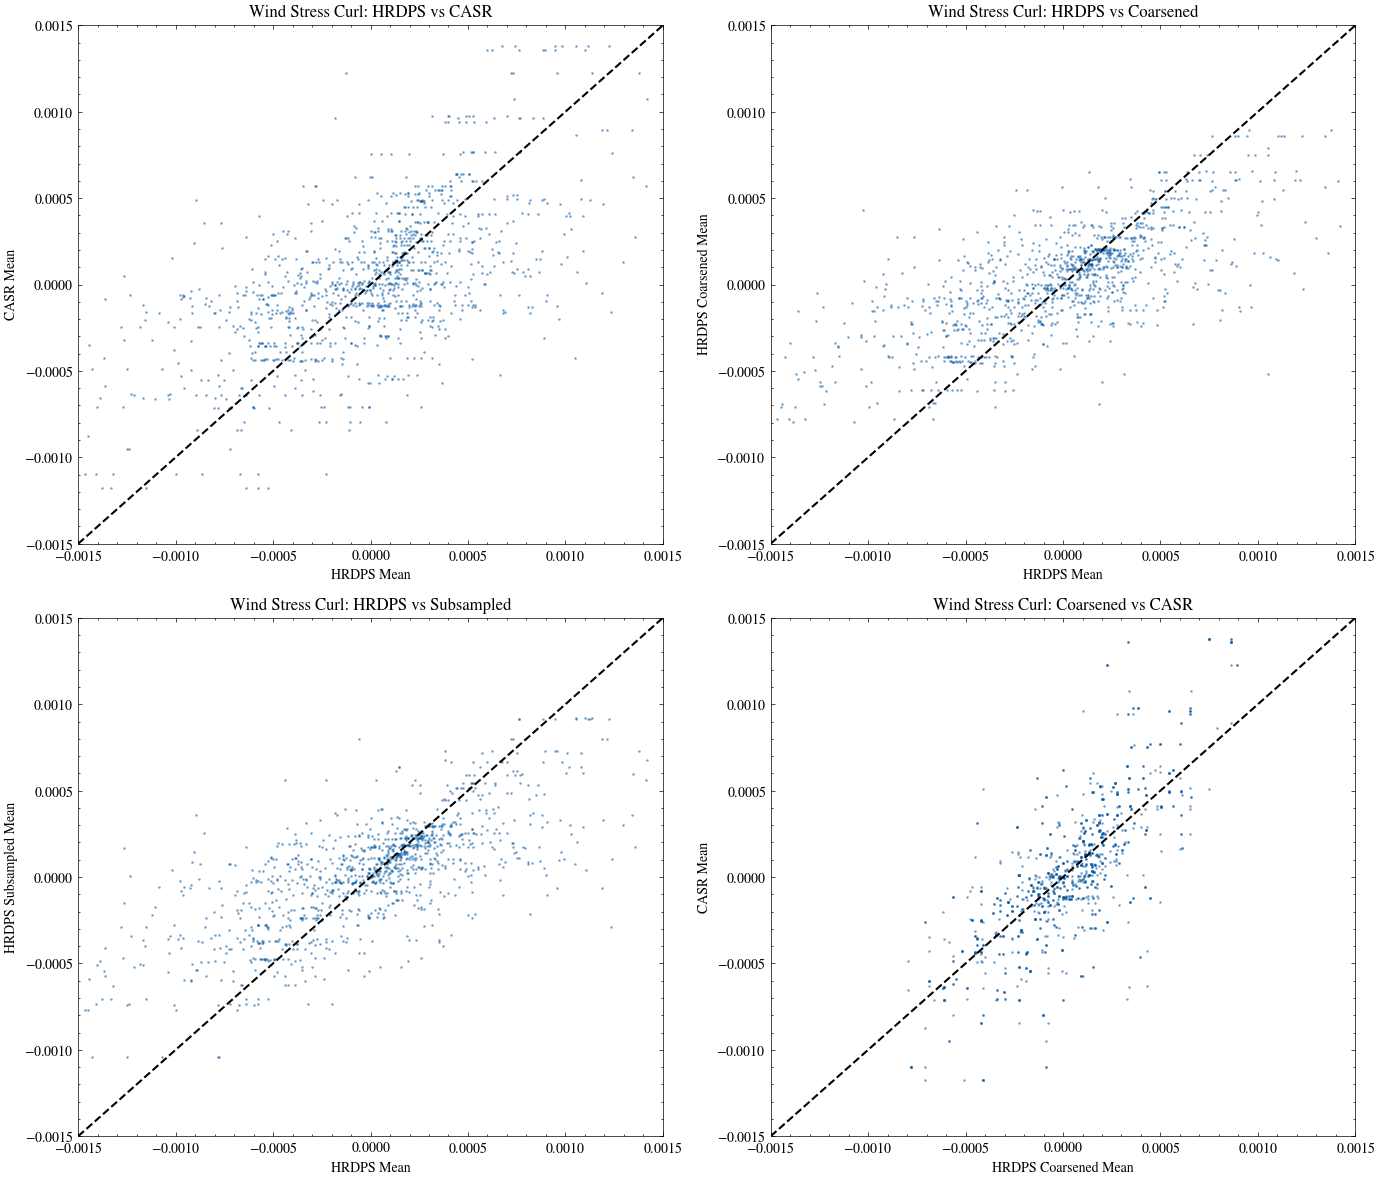

In [8]:
# Scatter Plot for wsc Wind Speed Mean

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_kwargs = {'s': 1, 'alpha': 0.4, 'color': 'C0'}
diag_kwargs = {'color': 'k', 'linestyle': '--', 'linewidth': 1.5}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  
        np.max([ax.get_xlim(), ax.get_ylim()]),  
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)


v_lims = [-0.0015, 0.0015] 

# Top-Left: 原版 HRDPS vs CASR
axes[0, 0].scatter(hrdps_wsc_mean, casr_wsc_mean, **scatter_kwargs)
axes[0, 0].set_xlim(v_lims)
axes[0, 0].set_ylim(v_lims)
add_diagonal_line(axes[0, 0])
axes[0, 0].set_title('Wind Stress Curl: HRDPS vs CASR')
axes[0, 0].set_xlabel('HRDPS Mean')
axes[0, 0].set_ylabel('CASR Mean')

# Top-Right: 原版 HRDPS vs Coarsened HRDPS
axes[0, 1].scatter(hrdps_wsc_mean, hrdps_c_wsc_mean, **scatter_kwargs)
axes[0, 1].set_xlim(v_lims)
axes[0, 1].set_ylim(v_lims)
add_diagonal_line(axes[0, 1])
axes[0, 1].set_title('Wind Stress Curl: HRDPS vs Coarsened')
axes[0, 1].set_xlabel('HRDPS Mean')
axes[0, 1].set_ylabel('HRDPS Coarsened Mean')

# Bottom-Left: 原版 HRDPS vs Subsampled HRDPS
axes[1, 0].scatter(hrdps_wsc_mean, hrdps_s_wsc_mean, **scatter_kwargs)
axes[1, 0].set_xlim(v_lims)
axes[1, 0].set_ylim(v_lims)
add_diagonal_line(axes[1, 0])
axes[1, 0].set_title('Wind Stress Curl: HRDPS vs Subsampled')
axes[1, 0].set_xlabel('HRDPS Mean')
axes[1, 0].set_ylabel('HRDPS Subsampled Mean')

# Bottom-Right: Coarsened HRDPS vs CASR (对比两个分辨率相近的模型)
axes[1, 1].scatter(hrdps_c_wsc_mean, casr_wsc_mean, **scatter_kwargs)
axes[1, 1].set_xlim(v_lims)
axes[1, 1].set_ylim(v_lims)
add_diagonal_line(axes[1, 1])
axes[1, 1].set_title('Wind Stress Curl: Coarsened vs CASR')
axes[1, 1].set_xlabel('HRDPS Coarsened Mean')
axes[1, 1].set_ylabel('CASR Mean')

plt.tight_layout()
plt.show()